In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "wandb", "huggingface_hub"], check=True)

import os, json, random, time, colorsys
import numpy as np
import cv2
from glob import glob
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms as T
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import wandb
from huggingface_hub import login, hf_hub_download

print("All imports done")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}, GPUs: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

All imports done
PyTorch: 2.10.0+cu128
CUDA available: True, GPUs: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


In [ ]:
#wandb.login(key="<>")  # replace with your key
#login(token="<>")

# ── Download & unzip ──────────────────────────────────────────────────────────
print("Downloading datasets from HuggingFace...")
for fname in ["train_clean.zip", "validation_clean.zip"]:
    hf_hub_download(
        repo_id="Harsh2005/DeepFashion2-Pruned",
        filename=fname,
        repo_type="dataset",
        local_dir="/kaggle/working"
    )

print("Unzipping...")
os.system("unzip -q /kaggle/working/train_clean.zip -d /kaggle/working/train")
os.system("unzip -q /kaggle/working/validation_clean.zip -d /kaggle/working/val")

for f in ["/kaggle/working/train_clean.zip", "/kaggle/working/validation_clean.zip"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"Removed {f}")

print("Data ready")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kronicposeidon to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


train_clean.zip:   0%|          | 0.00/7.99G [00:00<?, ?B/s]

validation_clean.zip:   0%|          | 0.00/1.32G [00:00<?, ?B/s]

Unzipping...
Removed /kaggle/working/train_clean.zip
Removed /kaggle/working/validation_clean.zip
Data ready


In [3]:
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_gpus   = torch.cuda.device_count()

BATCH_SIZE     = 2 * max(n_gpus, 1)   # 4 with 2x T4
NUM_WORKERS    = 4

TOTAL_ITERS    = 5_000
LOG_EVERY      = 5
VAL_EVERY      = 1_000
SAVE_EVERY     = 1_000
WARMUP_ITERS   = 1_000
VAL_BATCHES    = 20        # ← cap validation at 20 batches max

BASE_LR        = 0.005 * (BATCH_SIZE / 2)
MIN_LR         = 5e-5
WEIGHT_DECAY   = 1e-4
GRAD_CLIP      = 5.0
IMG_MAX_SIZE   = 512
SCORE_THRESH   = 0.50
MASK_THRESH    = 0.50

CATEGORIES = ["short sleeve top", "trousers", "shorts", "long sleeve top", "skirt"]
CAT_TO_IDX = {cat: i + 1 for i, cat in enumerate(CATEGORIES)}
IDX_TO_CAT = {v: k for k, v in CAT_TO_IDX.items()}
NUM_CLASSES = len(CATEGORIES) + 1

print(f"Device        : {device}")
print(f"GPUs          : {n_gpus}")
print(f"Batch size    : {BATCH_SIZE}")
print(f"Total iters   : {TOTAL_ITERS:,}")
print(f"Val / Save    : every {VAL_EVERY:,} iters  (capped at {VAL_BATCHES} batches)")
print(f"Base LR       : {BASE_LR:.4f}")

Device        : cuda
GPUs          : 2
Batch size    : 4
Total iters   : 5,000
Val / Save    : every 1,000 iters  (capped at 20 batches)
Base LR       : 0.0100


In [4]:
class FashionDetSegDataset(Dataset):
    """
    Loads DeepFashion2 annotations for detection + segmentation.
    Returns (image_tensor, target_dict) compatible with torchvision Mask R-CNN.
    """
    def __init__(self, root_dir, max_size=512):
        self.root_dir  = root_dir
        self.max_size  = max_size
        self.to_tensor = T.ToTensor()

        all_jsons = glob(os.path.join(root_dir, "**/*.json"), recursive=True)
        self.samples         = []   # list of json paths
        self.img_to_classes  = []   # list of sets, one per sample

        for jp in all_jsons:
            try:
                with open(jp) as fh:
                    ann = json.load(fh)
                valid_items = [
                    v for k, v in ann.items()
                    if k.startswith("item") and isinstance(v, dict)
                    and v.get("category_name") in CAT_TO_IDX
                    and "bounding_box" in v
                ]
                if valid_items:
                    self.samples.append(jp)
                    self.img_to_classes.append(
                        {CAT_TO_IDX[v["category_name"]] for v in valid_items}
                    )
            except Exception:
                pass

        print(f"  Loaded {len(self.samples):,} valid samples from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def _resize_img(self, img):
        w, h  = img.size
        scale = self.max_size / min(w, h)
        nw, nh = int(w * scale), int(h * scale)
        return img.resize((nw, nh), Image.BILINEAR), scale

    def __getitem__(self, idx):
        jp = self.samples[idx]
        with open(jp) as fh:
            ann = json.load(fh)

        # locate image file
        ip = jp.replace(".json", ".jpg").replace("annos", "image")
        if not os.path.exists(ip):
            ip = jp.replace(".json", ".jpg")

        img, scale = self._resize_img(Image.open(ip).convert("RGB"))
        W, H = img.size

        boxes, labels, masks = [], [], []

        for key, val in ann.items():
            if not (key.startswith("item") and isinstance(val, dict)):
                continue
            cat = val.get("category_name")
            if cat not in CAT_TO_IDX:
                continue
            bb = val.get("bounding_box")
            if not bb or len(bb) < 4:
                continue

            x1, y1, x2, y2 = (c * scale for c in bb)
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(W, x2), min(H, y2)
            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])
            labels.append(CAT_TO_IDX[cat])

            mask = np.zeros((H, W), dtype=np.uint8)
            for poly in val.get("segmentation", []):
                if len(poly) >= 6:
                    pts = (np.array(poly, dtype=np.float32).reshape(-1, 2) * scale).astype(np.int32)
                    cv2.fillPoly(mask, [pts], 1)
            if mask.sum() == 0:
                mask[int(y1):int(y2), int(x1):int(x2)] = 1
            masks.append(mask)

        if len(boxes) == 0:
            target = {
                "boxes":    torch.zeros((0, 4),    dtype=torch.float32),
                "labels":   torch.zeros((0,),      dtype=torch.int64),
                "masks":    torch.zeros((0, H, W), dtype=torch.uint8),
                "image_id": torch.tensor([idx]),
                "area":     torch.zeros((0,),      dtype=torch.float32),
                "iscrowd":  torch.zeros((0,),      dtype=torch.int64),
            }
        else:
            bt = torch.tensor(boxes, dtype=torch.float32)
            target = {
                "boxes":    bt,
                "labels":   torch.tensor(labels, dtype=torch.int64),
                "masks":    torch.tensor(np.stack(masks), dtype=torch.uint8),
                "image_id": torch.tensor([idx]),
                "area":     (bt[:, 3] - bt[:, 1]) * (bt[:, 2] - bt[:, 0]),
                "iscrowd":  torch.zeros(len(boxes), dtype=torch.int64),
            }

        return self.to_tensor(img), target


def collate_fn(batch):
    return tuple(zip(*batch))

In [5]:
print("Scanning annotation files (this takes ~1-2 min)...")

train_dataset = FashionDetSegDataset("/kaggle/working/train/train",      max_size=IMG_MAX_SIZE)
val_dataset   = FashionDetSegDataset("/kaggle/working/val/validation",   max_size=IMG_MAX_SIZE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    pin_memory=True,
    persistent_workers=True,
)

iters_per_epoch = len(train_dataset) // BATCH_SIZE
print(f"\nTrain samples  : {len(train_dataset):,}")
print(f"Val   samples  : {len(val_dataset):,}")
print(f"Train batches  : {len(train_loader):,}")
print(f"Iters/epoch    : {iters_per_epoch:,}")
print(f"Total iters    : {TOTAL_ITERS:,}  (~{TOTAL_ITERS/iters_per_epoch:.1f} epochs)")

Scanning annotation files (this takes ~1-2 min)...
  Loaded 144,174 valid samples from /kaggle/working/train/train
  Loaded 23,741 valid samples from /kaggle/working/val/validation

Train samples  : 144,174
Val   samples  : 23,741
Train batches  : 36,044
Iters/epoch    : 36,043
Total iters    : 5,000  (~0.1 epochs)


In [6]:
def build_model(num_classes=NUM_CLASSES):
    net = maskrcnn_resnet50_fpn(
        weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT,
        rpn_pre_nms_top_n_train=1000,
        rpn_post_nms_top_n_train=500,
        rpn_pre_nms_top_n_test=500,
        rpn_post_nms_top_n_test=250,
        box_detections_per_img=50,
    )
    # replace box head
    in_box  = net.roi_heads.box_predictor.cls_score.in_features
    net.roi_heads.box_predictor = FastRCNNPredictor(in_box, num_classes)
    # replace mask head
    in_mask = net.roi_heads.mask_predictor.conv5_mask.in_channels
    net.roi_heads.mask_predictor = MaskRCNNPredictor(in_mask, 256, num_classes)
    return net


model = build_model().to(device)

# DataParallel across both T4s
# NOTE: torchvision detection models don't support DistributedDataParallel easily,
# but nn.DataParallel works fine for inference; for training we keep single-GPU
# and rely on batch-size scaling.  If you want both GPUs during training uncomment:
# model = nn.DataParallel(model)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Mask R-CNN built")
print(f"  Total params     : {total_p/1e6:.1f} M")
print(f"  Trainable params : {trainable_p/1e6:.1f} M")

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 185MB/s]


Mask R-CNN built
  Total params     : 43.9 M
  Trainable params : 43.7 M


In [7]:
param_list = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    param_list,
    lr=BASE_LR,
    momentum=0.9,
    weight_decay=WEIGHT_DECAY,
)

# Cosine decay after warmup — we'll handle warmup manually
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=TOTAL_ITERS - WARMUP_ITERS,
    eta_min=MIN_LR,
)

scaler = torch.amp.GradScaler("cuda")

def get_lr(it):
    """Linear warmup then cosine handled by scheduler; this just does warmup."""
    if it < WARMUP_ITERS:
        return BASE_LR * (it + 1) / WARMUP_ITERS
    return None   # let scheduler handle it

print(f"Optimizer : SGD  lr={BASE_LR:.4f}  momentum=0.9  wd={WEIGHT_DECAY}")
print(f"Scheduler : CosineAnnealingLR  T_max={TOTAL_ITERS - WARMUP_ITERS:,}  eta_min={MIN_LR}")
print(f"AMP scaler ready")

Optimizer : SGD  lr=0.0100  momentum=0.9  wd=0.0001
Scheduler : CosineAnnealingLR  T_max=4,000  eta_min=5e-05
AMP scaler ready


In [8]:
def box_iou_matrix(boxes_a, boxes_b):
    ax1,ay1,ax2,ay2 = boxes_a[:,0],boxes_a[:,1],boxes_a[:,2],boxes_a[:,3]
    bx1,by1,bx2,by2 = boxes_b[:,0],boxes_b[:,1],boxes_b[:,2],boxes_b[:,3]
    ix1 = np.maximum(ax1[:,None], bx1[None,:])
    iy1 = np.maximum(ay1[:,None], by1[None,:])
    ix2 = np.minimum(ax2[:,None], bx2[None,:])
    iy2 = np.minimum(ay2[:,None], by2[None,:])
    inter = np.maximum(0, ix2-ix1) * np.maximum(0, iy2-iy1)
    area_a = (ax2-ax1)*(ay2-ay1)
    area_b = (bx2-bx1)*(by2-by1)
    return inter / (area_a[:,None] + area_b[None,:] - inter + 1e-6)


def ap_from_pr(recalls, precisions):
    mr = np.concatenate(([0.], recalls,    [1.]))
    mp = np.concatenate(([0.], precisions, [0.]))
    for i in range(len(mp)-2, -1, -1):
        mp[i] = max(mp[i], mp[i+1])
    idx = np.where(mr[1:] != mr[:-1])[0]
    return float(np.sum((mr[idx+1] - mr[idx]) * mp[idx+1]))


@torch.no_grad()
def run_evaluation(net, loader, dev, iou_thresholds=np.linspace(0.5, 0.95, 10)):
    net.eval()
    records      = []
    n_gt_per_cls = defaultdict(int)
    pixel_stats  = defaultdict(lambda: np.array([0, 0, 0], dtype=np.int64))

    for batch_i, (images, targets) in enumerate(tqdm(loader, desc="Evaluating", leave=False)):
        if batch_i >= VAL_BATCHES:          # ← hard cap
            break

        imgs  = [img.to(dev) for img in images]
        preds = net(imgs)

        for pred, tgt in zip(preds, targets):
            gt_boxes  = tgt["boxes"].numpy()
            gt_labels = tgt["labels"].numpy()
            gt_masks  = tgt["masks"].numpy()

            pb     = pred["boxes"].cpu().numpy()
            pl     = pred["labels"].cpu().numpy()
            ps     = pred["scores"].cpu().numpy()
            pm     = pred["masks"].cpu().numpy()
            pm_bin = (pm[:, 0] >= MASK_THRESH).astype(np.uint8)

            for lbl in gt_labels:
                n_gt_per_cls[lbl] += 1

            for cls_id in range(1, NUM_CLASSES):
                p_mask_c  = pl == cls_id
                gt_mask_c = gt_labels == cls_id
                pb_c, ps_c = pb[p_mask_c], ps[p_mask_c]
                gb_c = gt_boxes[gt_mask_c]

                if len(pb_c) == 0:
                    continue

                order    = np.argsort(-ps_c)
                pb_c, ps_c = pb_c[order], ps_c[order]

                tps = np.zeros((len(pb_c), len(iou_thresholds)))
                if len(gb_c) > 0:
                    iou_mat = box_iou_matrix(pb_c, gb_c)
                    used_gt = [set() for _ in iou_thresholds]
                    for pi in range(len(pb_c)):
                        for ti, thr in enumerate(iou_thresholds):
                            best_gi = iou_mat[pi].argmax()
                            if iou_mat[pi, best_gi] >= thr and best_gi not in used_gt[ti]:
                                tps[pi, ti] = 1
                                used_gt[ti].add(best_gi)

                for pi in range(len(pb_c)):
                    records.append({"score": ps_c[pi], "tps": tps[pi], "cls": cls_id})

            for cls_id in range(1, NUM_CLASSES):
                p_idx_c  = np.where(pl == cls_id)[0]
                gt_idx_c = np.where(gt_labels == cls_id)[0]

                keep_c  = ps[p_idx_c] >= SCORE_THRESH
                p_idx_c = p_idx_c[keep_c]

                if len(p_idx_c):
                    order   = np.argsort(-ps[p_idx_c])
                    p_idx_c = p_idx_c[order]

                matched_gt, matched_p = set(), set()
                if len(gt_idx_c) > 0 and len(p_idx_c) > 0:
                    iou_mat = box_iou_matrix(pb[p_idx_c], gt_boxes[gt_idx_c])
                    for pi_local, pi in enumerate(p_idx_c):
                        best_local = iou_mat[pi_local].argmax()
                        best_gi    = gt_idx_c[best_local]
                        if iou_mat[pi_local, best_local] >= 0.5 and best_gi not in matched_gt:
                            pred_m = pm_bin[pi].astype(bool)
                            gt_m   = gt_masks[best_gi].astype(bool)
                            pixel_stats[cls_id] += [
                                int((pred_m &  gt_m).sum()),
                                int((pred_m & ~gt_m).sum()),
                                int((~pred_m & gt_m).sum()),
                            ]
                            matched_gt.add(best_gi)
                            matched_p.add(pi)
                        else:
                            pixel_stats[cls_id] += [0, int(pm_bin[pi].sum()), 0]

                for gi in gt_idx_c:
                    if gi not in matched_gt:
                        pixel_stats[cls_id] += [0, 0, int(gt_masks[gi].sum())]

    per_class  = {}
    map_values = []

    for cls_id in range(1, NUM_CLASSES):
        cls_recs = sorted([r for r in records if r["cls"] == cls_id],
                          key=lambda x: -x["score"])
        if not cls_recs or n_gt_per_cls[cls_id] == 0:
            per_class[cls_id] = {"mAP_50_95": 0, "mAP_50": 0, "f1": 0, "iou": 0, "dice": 0}
            continue

        tp_matrix = np.array([r["tps"] for r in cls_recs])
        aps = []
        for ti in range(len(iou_thresholds)):
            tp_c  = tp_matrix[:, ti].cumsum()
            fp_c  = (1 - tp_matrix[:, ti]).cumsum()
            prec  = tp_c / (tp_c + fp_c + 1e-6)
            rec   = tp_c / (n_gt_per_cls[cls_id] + 1e-6)
            aps.append(ap_from_pr(rec, prec))

        tp0   = tp_matrix[:, 0].cumsum()
        fp0   = (1 - tp_matrix[:, 0]).cumsum()
        prec0 = tp0 / (tp0 + fp0 + 1e-6)
        rec0  = tp0 / (n_gt_per_cls[cls_id] + 1e-6)
        f1    = float(np.max(2 * prec0 * rec0 / (prec0 + rec0 + 1e-6)))

        tp_px, fp_px, fn_px = pixel_stats[cls_id]
        pix_iou  = tp_px / (tp_px + fp_px + fn_px + 1e-6)
        pix_dice = 2 * tp_px / (2 * tp_px + fp_px + fn_px + 1e-6)

        per_class[cls_id] = {
            "mAP_50_95": float(np.mean(aps)),
            "mAP_50":    float(aps[0]),
            "f1":        f1,
            "iou":       float(pix_iou),
            "dice":      float(pix_dice),
        }
        map_values.append(float(np.mean(aps)))

    overall_map = float(np.mean(map_values)) if map_values else 0.0
    return overall_map, per_class


print("Evaluation helpers defined")

Evaluation helpers defined


In [9]:
# ── Init WandB ────────────────────────────────────────────────────────────────
run = wandb.init(
    project="deepfashion2-maskrcnn",
    name="maskrcnn-iterative",
    config={
        "batch_size":   BATCH_SIZE,
        "total_iters":  TOTAL_ITERS,
        "base_lr":      BASE_LR,
        "min_lr":       MIN_LR,
        "warmup_iters": WARMUP_ITERS,
        "img_max_size": IMG_MAX_SIZE,
        "val_every":    VAL_EVERY,
        "save_every":   SAVE_EVERY,
        "val_batches":  VAL_BATCHES,
        "categories":   CATEGORIES,
        "num_classes":  NUM_CLASSES,
    },
    save_code=True,
)

print(f"WandB run : {run.name}")
print(f"WandB url : {run.url}")

# ── Infinite dataloader ───────────────────────────────────────────────────────
def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch

data_stream = infinite_loader(train_loader)
global_iter = 0
best_map    = 0.0
running     = defaultdict(float)

model.train()
t_start = time.time()

print(f"\nStarting — {TOTAL_ITERS:,} iters  |  log every {LOG_EVERY}  |  val+save every {VAL_EVERY:,}")
print("-" * 60)

# ── Main loop ─────────────────────────────────────────────────────────────────
while global_iter < TOTAL_ITERS:

    images, targets = next(data_stream)
    images  = [img.to(device) for img in images]
    targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

    # ── Warmup LR ─────────────────────────────────────────────────────────────
    if global_iter < WARMUP_ITERS:
        new_lr = BASE_LR * (global_iter + 1) / WARMUP_ITERS
        for pg in optimizer.param_groups:
            pg["lr"] = new_lr

    # ── Forward + backward ────────────────────────────────────────────────────
    optimizer.zero_grad()
    with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
        loss_dict  = model(images, targets)
        total_loss = sum(loss_dict.values())

    scaler.scale(total_loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(param_list, GRAD_CLIP)
    scaler.step(optimizer)
    scaler.update()

    if global_iter >= WARMUP_ITERS:
        scheduler.step()

    global_iter += 1

    running["total"] += total_loss.item()
    for k, v in loss_dict.items():
        running[k] += v.item()

    # ── Loss logging ──────────────────────────────────────────────────────────
    if global_iter % LOG_EVERY == 0:
        cur_lr  = optimizer.param_groups[0]["lr"]
        elapsed = time.time() - t_start
        avg     = {k: v / LOG_EVERY for k, v in running.items()}

        wandb.log({
            "train/loss_total":      avg["total"],
            "train/loss_classifier": avg.get("loss_classifier", 0),
            "train/loss_box_reg":    avg.get("loss_box_reg", 0),
            "train/loss_mask":       avg.get("loss_mask", 0),
            "train/loss_objectness": avg.get("loss_objectness", 0),
            "train/loss_rpn_box":    avg.get("loss_rpn_box_reg", 0),
            "train/lr":              cur_lr,
            "train/elapsed_min":     elapsed / 60,
        }, step=global_iter)

        if global_iter % 500 == 0:
            print(f"[{global_iter:>6,}/{TOTAL_ITERS:,}]  "
                  f"loss={avg['total']:.4f}  lr={cur_lr:.2e}  "
                  f"time={elapsed/60:.1f}min")

        running = defaultdict(float)

    # ── Val + Save ────────────────────────────────────────────────────────────
    if global_iter % VAL_EVERY == 0 or global_iter == TOTAL_ITERS:
        print(f"\n{'='*60}")
        print(f"[iter {global_iter:,}]  Running validation (max {VAL_BATCHES} batches)...")

        overall_map, cls_metrics = run_evaluation(model, val_loader, device)

        # ── Log metrics to WandB ──────────────────────────────────────────────
        val_log = {
            "val/mAP_50_95": overall_map,
            "val/mean_iou":  float(np.mean([cls_metrics[c].get("iou",  0) for c in range(1, NUM_CLASSES)])),
            "val/mean_dice": float(np.mean([cls_metrics[c].get("dice", 0) for c in range(1, NUM_CLASSES)])),
            "val/mean_f1":   float(np.mean([cls_metrics[c].get("f1",   0) for c in range(1, NUM_CLASSES)])),
        }

        print(f"  Overall mAP@[.5:.95] = {overall_map:.4f}")
        print(f"  {'Category':<22} mAP@.5:.95  mAP@.50   F1      IoU     Dice")
        print(f"  {'-'*72}")
        for cid in range(1, NUM_CLASSES):
            m    = cls_metrics.get(cid, {})
            name = IDX_TO_CAT[cid]
            print(f"  {name:<22} "
                  f"{m.get('mAP_50_95',0):.4f}      "
                  f"{m.get('mAP_50',0):.4f}   "
                  f"{m.get('f1',0):.4f}  "
                  f"{m.get('iou',0):.4f}  "
                  f"{m.get('dice',0):.4f}")
            val_log[f"val/{name}/mAP_50_95"] = m.get("mAP_50_95", 0)
            val_log[f"val/{name}/mAP_50"]    = m.get("mAP_50",    0)
            val_log[f"val/{name}/f1"]        = m.get("f1",        0)
            val_log[f"val/{name}/iou"]       = m.get("iou",       0)
            val_log[f"val/{name}/dice"]      = m.get("dice",      0)

        wandb.log(val_log, step=global_iter)

        # ── Save checkpoint ───────────────────────────────────────────────────
        ckpt_path = f"/kaggle/working/maskrcnn_iter_{global_iter}.pth"
        torch.save(model.state_dict(), ckpt_path)
        wandb.save(ckpt_path)
        print(f"  Saved → {ckpt_path}")

        # ── Save best ─────────────────────────────────────────────────────────
        if overall_map > best_map:
            best_map  = overall_map
            best_path = "/kaggle/working/maskrcnn_best.pth"
            torch.save(model.state_dict(), best_path)
            wandb.save(best_path)
            print(f"  New best mAP={best_map:.4f} → saved {best_path}")

        print(f"{'='*60}\n")
        model.train()

print(f"\nDone — {global_iter:,} iters  |  best mAP = {best_map:.4f}")
wandb.finish()

wandb: setting up run 2r77qwd1
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260330_131400-2r77qwd1
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run maskrcnn-iterative
wandb: ⭐️ View project at https://wandb.ai/kronicposeidon/deepfashion2-maskrcnn
wandb: 🚀 View run at https://wandb.ai/kronicposeidon/deepfashion2-maskrcnn/runs/2r77qwd1


WandB run : maskrcnn-iterative
WandB url : https://wandb.ai/kronicposeidon/deepfashion2-maskrcnn/runs/2r77qwd1

Starting — 5,000 iters  |  log every 5  |  val+save every 1,000
------------------------------------------------------------
[   500/5,000]  loss=0.5533  lr=5.00e-03  time=6.1min
[ 1,000/5,000]  loss=0.4569  lr=1.00e-02  time=12.3min

[iter 1,000]  Running validation (max 20 batches)...


  Overall mAP@[.5:.95] = 0.4551
  Category               mAP@.5:.95  mAP@.50   F1      IoU     Dice
  ------------------------------------------------------------------------
  short sleeve top       0.5316      0.7276   0.6957  0.5186  0.6830
  trousers               0.5018      0.7687   0.7778  0.5677  0.7243
  shorts                 0.4661      0.6788   0.6207  0.5796  0.7338
  long sleeve top        0.3031      0.4634   0.4706  0.1047  0.1895
  skirt                  0.4728      0.6778   0.6667  0.1636  0.2812


wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


  Saved → /kaggle/working/maskrcnn_iter_1000.pth


...

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


  Saved → /kaggle/working/maskrcnn_iter_5000.pth


wandb: updating run metadata


  New best mAP=0.6869 → saved /kaggle/working/maskrcnn_best.pth


Done — 5,000 iters  |  best mAP = 0.6869


wandb: uploading history steps 998-999, summary, console lines 80-98
wandb: uploading working/maskrcnn_best.pth; uploading output.log; uploading wandb-summary.json; uploading config.yaml
wandb: uploading working/maskrcnn_best.pth
wandb: uploading working/maskrcnn_iter_5000.pth
wandb: 
wandb: Run history:
wandb:        train/elapsed_min ▁▁▁▁▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
wandb:       train/loss_box_reg ▆▆█▇▄▄▃▃▃▄▃▃▂▃▃▃▃▃▂▂▁▂▂▂▃▁▂▁▂▂▂▁▁▁▂▂▂▂▁▂
wandb:    train/loss_classifier █▂▂▂▂▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:          train/loss_mask █▇▅▃▄▄▄▅▄▇▃▆▄▄▃▃▅▄▄▂▃▅▂▂▂▅▄▂▂▂▂▁▂▃▃▃▂▁▁▂
wandb:    train/loss_objectness █▂▃▂▂▆▂▂▂▂▃▁▃▂▁▂▂▁▅▂▁▁▂▁▂▁▃▁▃▂▂▁▁▁▁▁▂▂▁▁
wandb:       train/loss_rpn_box █▄▅█▇▃▅▃▃▂▄▄▃▃▄▅▆▅▄▃▄▃▆▄▃▃▃▅▅▄▂▃▃▄▁▃▄▂▃▂
wandb:         train/loss_total █▅▄▄▃▃▃▃▂▃▃▃▂▃▂▂▂▂▃▃▂▂▃▂▂▂▁▂▂▂▂▂▂▂▃▁▂▂▁▁
wandb:                 train/lr ▁▁▂▃▆▇▇████████▇▇▇▆▆▆▅▅▅▅▃▃▃▃▃▂▁▁▁▁▁▁▁▁▁
wandb: val/long sleeve top/dice ▁▄███
wandb:   val/long sleeve top/f1 ▁▅▇██
wandb:                      +27 ..

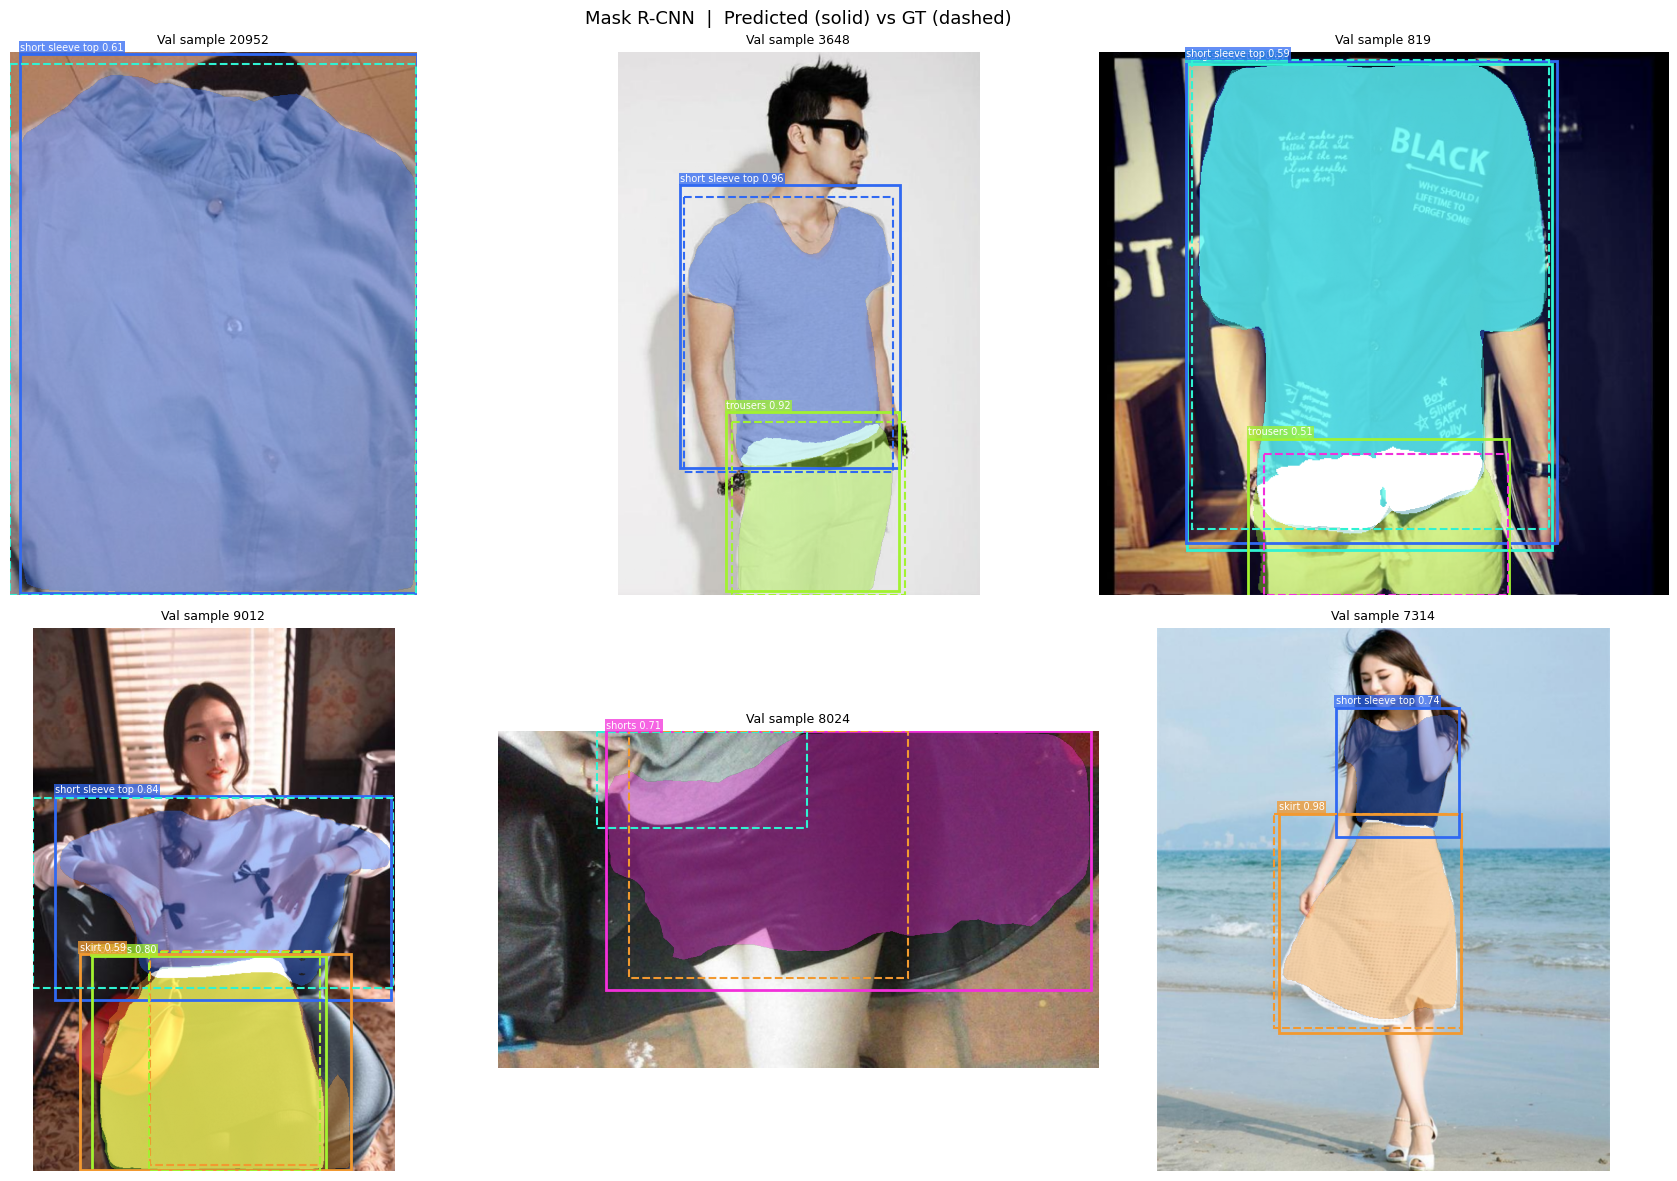

wandb: setting up run kwrkqwec
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260330_141658-kwrkqwec
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run visualisation
wandb: ⭐️ View project at https://wandb.ai/kronicposeidon/deepfashion2-maskrcnn
wandb: 🚀 View run at https://wandb.ai/kronicposeidon/deepfashion2-maskrcnn/runs/kwrkqwec
wandb: updating run metadata; uploading summary
wandb: uploading summary; uploading media/images/predictions_0_a4b9cd67fb12fea46d99.png
wandb: uploading summary
wandb: uploading history steps 0-0, summary
wandb: 🚀 View run visualisation at: https://wandb.ai/kronicposeidon/deepfashion2-maskrcnn/runs/kwrkqwec
wandb: ⭐️ View project at: https://wandb.ai/kronicposeidon/deepfashion2-maskrcnn
wandb: Synced 4 W&B file(s), 1 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260330_141658-kwrkqwec/logs


Saved + logged → maskrcnn_predictions.png


In [10]:
# ── Load best weights ─────────────────────────────────────────────────────────
model_vis = build_model(NUM_CLASSES).to(device)
model_vis.load_state_dict(
    torch.load("/kaggle/working/maskrcnn_best.pth", map_location=device)
)
model_vis.eval()

def class_color(cls_id):
    h = (cls_id * 0.618033988749895) % 1.0
    return colorsys.hsv_to_rgb(h, 0.8, 0.95)

N_VIS = 6
random.seed(42)
vis_idx = random.sample(range(len(val_dataset)), min(N_VIS, len(val_dataset)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax_i, vi in enumerate(vis_idx):
    img_t, tgt = val_dataset[vi]
    img_np = img_t.permute(1, 2, 0).numpy()
    H, W   = img_np.shape[:2]
    ax     = axes[ax_i]
    ax.imshow(img_np)

    with torch.no_grad():
        pred = model_vis([img_t.to(device)])[0]

    pb = pred["boxes"].cpu().numpy()
    pl = pred["labels"].cpu().numpy()
    ps = pred["scores"].cpu().numpy()
    pm = pred["masks"].cpu().numpy()

    # translucent mask overlay
    canvas = np.zeros((H, W, 4), dtype=float)
    for box, lbl, score, mask in zip(pb, pl, ps, pm):
        if score < SCORE_THRESH:
            continue
        c = class_color(lbl)
        m = (mask[0] >= MASK_THRESH).astype(float)
        canvas[:,:,0] += c[0] * m
        canvas[:,:,1] += c[1] * m
        canvas[:,:,2] += c[2] * m
        canvas[:,:,3] += 0.40  * m
    ax.imshow(np.clip(canvas, 0, 1))

    # predicted boxes
    for box, lbl, score in zip(pb, pl, ps):
        if score < SCORE_THRESH:
            continue
        x1,y1,x2,y2 = box
        c = class_color(lbl)
        ax.add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1, lw=2, edgecolor=c, facecolor="none"))
        ax.text(x1, y1-4, f"{IDX_TO_CAT.get(lbl, lbl)} {score:.2f}",
                fontsize=7, color="white",
                bbox=dict(facecolor=c, alpha=0.75, pad=1, edgecolor="none"))

    # ground-truth boxes (dashed)
    for gb, gl in zip(tgt["boxes"].numpy(), tgt["labels"].numpy()):
        x1,y1,x2,y2 = gb
        ax.add_patch(patches.Rectangle(
            (x1,y1), x2-x1, y2-y1, lw=1.5,
            edgecolor=class_color(gl), facecolor="none", linestyle="--"))

    ax.set_title(f"Val sample {vi}", fontsize=9)
    ax.axis("off")

plt.suptitle("Mask R-CNN  |  Predicted (solid) vs GT (dashed)", fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/maskrcnn_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

# log visualisation to wandb
run_vis = wandb.init(project="deepfashion2-maskrcnn", name="visualisation", resume="allow")
run_vis.log({"predictions": wandb.Image("/kaggle/working/maskrcnn_predictions.png")})
wandb.finish()
print("Saved + logged → maskrcnn_predictions.png")